### Import statements and loading preprocessed data

In [3]:
import mne
import numpy as np
import pandas as pd

# Define some parameters
analysis_params = {
        'win_dur': 0.2,
        'win_step': 0.05, 
        'tmin_plot': -0.5, 
        'tmax_plot': 2.0
    }

# Load some sample data to get data object information
subject = 'S25_245'
fn_prefix = f'../../derivatives/pulse_labels/{subject}'
epochs_trigger = mne.read_epochs(f"{fn_prefix}_trigs-epo.fif", verbose=False)
epochs_trigger = epochs_trigger.crop(tmin=-1, tmax=2.3) 

# Define the windows used for earlier analysis
tfr_times = epochs_trigger.times
win_starts = np.arange(analysis_params['tmin_plot'], analysis_params['tmax_plot'] - analysis_params['win_dur'], analysis_params['win_step'])
win_centers = win_starts + (analysis_params['win_dur'] / 2)
frequencies = np.logspace(np.log10(4), np.log10(180), 35)

# Load processed DataFrame
hfa = pd.read_pickle('../outputs/iTBS_multitaper_HFA_onlyHigh_0.2dur_0.05step_outliersExcluded.pkl')

/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_40283/613097562.py:16: RuntimeWarning: The events passed to the Epochs constructor are not chronologically ordered.
  epochs_trigger = mne.read_epochs(f"{fn_prefix}_trigs-epo.fif", verbose=False)
/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_40283/613097562.py:16: RuntimeWarning: The events passed to the Epochs constructor are not chronologically ordered.
  epochs_trigger = mne.read_epochs(f"{fn_prefix}_trigs-epo.fif", verbose=False)


In [4]:
bad_elec_keywords = 'out|lesion|damage|empty|unknown' 

# Grab desired subset of subjects/electrodes
plot_subset = hfa[ 
                        (~hfa['jp_channel_1'].astype(str).str.contains(bad_elec_keywords, case=False)) & 
                        (hfa['is_bad'] == False) &
                        (hfa['is_lead'] == False) &
                        (hfa['baseline_ptp']>10) &
                        (hfa['subject'].str.contains('')) &    
                        (hfa['channel'].str.contains(''))  
                            ]

#### Extract data from saved TFRs into canonical bands
Loads from preprocessed single-subject dataframes (see population_preprocessing.ipynb) and organizes into pre, post, and power difference columns

In [7]:
import numpy as np
import pandas as pd
import os
from scipy.stats import ttest_ind

# --- 1. User-Defined Extraction Parameters ---
blocks_of_interest = ['iTBS1', 'iTBS2', 'iTBS3']

# Define your target Region of Interest (ROI)
target_time_window = [0.7, 0.85] 
target_freq_band = [75, 180]      # e.g., HFA

# Create boolean masks based on your global frequency/time arrays
# (Assuming 'frequencies' and 'win_centers' are already loaded in your environment)
f_mask = (frequencies >= target_freq_band[0]) & (frequencies <= target_freq_band[1])
t_mask = (win_centers >= target_time_window[0]) & (win_centers <= target_time_window[1])

# Define the file templates for Active vs Sham
conditions = {
    'Active': '../outputs/subject_level/{sub_id}_tfr_df.pkl',
    'Sham': '../outputs/subject_level/{sub_id}_Shamtfr_df.pkl'
}

extracted_records = []

print(f"Extracting data for {len(plot_subset)} electrodes across Active and Sham conditions...")

# --- 2. Loop Through Conditions and Electrodes ---
for cond_name, file_template in conditions.items():
    data_cache = {}
    
    for idx, row in plot_subset.iterrows():
        sub_id = row['subject']
        block_id = row['block']
        target_chan = row['channel']
        
        if block_id not in blocks_of_interest:
            continue

        # Load file into cache if not already loaded
        if sub_id not in data_cache:
            file_path = file_template.format(sub_id=sub_id)
            if os.path.exists(file_path):
                data_cache[sub_id] = pd.read_pickle(file_path)
            else:
                data_cache[sub_id] = None # Mark as missing
                
        sub_df = data_cache[sub_id]
        if sub_df is None:
            continue
            
        block_data = sub_df[sub_df['block'] == block_id]
        if block_data.empty:
            continue
            
        chan_list = block_data['channels'].iloc[0]
        try:
            chan_idx = chan_list.index(target_chan)
        except ValueError:
            continue
            
        pre_tfr_raw = block_data['pre_tfr'].iloc[0]
        post_tfr_raw = block_data['post_tfr'].iloc[0]
        
        if pre_tfr_raw is None or post_tfr_raw is None:
            continue

        # --- 3. Extract ROI and Calculate Stats ---
        # Slice to the specific channel, frequency band, and time window
        # Shape goes from (epochs, channels, freqs, times) -> (epochs, roi_freqs, roi_times)
        pre_roi = pre_tfr_raw[:, chan_idx, f_mask, :][:, :, t_mask]
        post_roi = post_tfr_raw[:, chan_idx, f_mask, :][:, :, t_mask]
        
        # Average across frequencies and times to get a single value per epoch
        pre_epoch_means = np.nanmean(pre_roi, axis=(1, 2))
        post_epoch_means = np.nanmean(post_roi, axis=(1, 2))
        
        # Overall average power across all epochs for this electrode
        pre_pwr_avg = np.nanmean(pre_epoch_means)
        post_pwr_avg = np.nanmean(post_epoch_means)
        
        # Calculate t-statistic comparing post vs pre across epochs
        t_val, p_val = ttest_ind(post_epoch_means, pre_epoch_means, nan_policy='omit')
        
        # Save to our records list
        extracted_records.append({
            'subject': sub_id,
            'block': block_id,
            'channel': target_chan,
            'condition': cond_name,
            'pre_power': pre_pwr_avg,
            'post_power': post_pwr_avg,
            'power_diff': post_pwr_avg - pre_pwr_avg,
            't_stat': t_val,
            'p_val': p_val
        })

# --- 4. Finalize DataFrame ---
df_results = pd.DataFrame(extracted_records)

print(f"Extraction complete! Created a DataFrame with {len(df_results)} rows.")
display(df_results.head())

Extracting data for 197 electrodes across Active and Sham conditions...


/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_40283/1435773133.py:75: RuntimeWarning: Mean of empty slice
  pre_epoch_means = np.nanmean(pre_roi, axis=(1, 2))
/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_40283/1435773133.py:76: RuntimeWarning: Mean of empty slice
  post_epoch_means = np.nanmean(post_roi, axis=(1, 2))
/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_40283/1435773133.py:75: RuntimeWarning: Mean of empty slice
  pre_epoch_means = np.nanmean(pre_roi, axis=(1, 2))
/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_40283/1435773133.py:76: RuntimeWarning: Mean of empty slice
  post_epoch_means = np.nanmean(post_roi, axis=(1, 2))
/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_40283/1435773133.py:75: RuntimeWarning: Mean of empty slice
  pre_epoch_means = np.nanmean(pre_roi, axis=(1, 2))
/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_40283/1435773133.py:76: RuntimeWarning: Mean of empty slice
  post_epoch_mean

Extraction complete! Created a DataFrame with 390 rows.


/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_40283/1435773133.py:75: RuntimeWarning: Mean of empty slice
  pre_epoch_means = np.nanmean(pre_roi, axis=(1, 2))
/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_40283/1435773133.py:76: RuntimeWarning: Mean of empty slice
  post_epoch_means = np.nanmean(post_roi, axis=(1, 2))
/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_40283/1435773133.py:75: RuntimeWarning: Mean of empty slice
  pre_epoch_means = np.nanmean(pre_roi, axis=(1, 2))


,subject,block,channel,condition,pre_power,post_power,power_diff,t_stat,p_val
0,S25_245,iTBS1,LLOF7-LLOF8,Active,-0.002030,-0.149405,-0.147375,-3.504703,0.001016
1,S25_245,iTBS2,LLOF7-LLOF8,Active,-0.049759,-0.047133,0.002627,0.056892,0.954849
2,S25_245,iTBS3,LLOF7-LLOF8,Active,0.029303,-0.003463,-0.032766,-0.554988,0.581378
3,S25_248,iTBS1,LHPA8-LHPA9,Active,0.084833,0.044860,-0.039973,-0.402377,0.689056
4,S25_248,iTBS1,LHPA9-LHPA10,Active,-0.015943,0.034576,0.050519,0.814650,0.419296


#### Run LME to test for significance of a given frequency/block combination

In [8]:
import statsmodels.formula.api as smf
from patsy.contrasts import Sum

test_subset = df_results[(df_results['condition']=='Active') &
                        (df_results['block'].str.contains(''))
                        ]

use_block_avg = False  # a good sanity check

# 1. Clean data
df_lme = test_subset.copy()
df_lme = df_lme.dropna(subset=['pre_power', 'post_power', 't_stat']).copy()

# Try averaging across blocks first and not including block as a factor
df_block_avg = df_lme.groupby(['subject', 'channel'])['t_stat'].mean().reset_index()

# 2. Define the Model

if use_block_avg:

    formula = "t_stat ~ 1"
    
    # 3. Fit the Model
    model = smf.mixedlm(formula, df_block_avg, groups=df_block_avg["subject"],)
    result = model.fit()

else:

    formula = "t_stat ~ C(block, Sum)"
    
    # 3. Fit the Model
    model = smf.mixedlm(formula, df_lme, groups=df_lme["subject"],
                       )
    result = model.fit()

# 4. Output
print("\n" + "="*60)
print("TARGET-LEVEL REPEATED MEASURES LME")
print(f"Total Observations: {len(df_lme)}")
print(f"Unique Sites (Groups): {df_lme['subject'].nunique()}")
print("="*60)
print(result.summary())


TARGET-LEVEL REPEATED MEASURES LME
Total Observations: 197
Unique Sites (Groups): 12
              Mixed Linear Model Regression Results
Model:                MixedLM    Dependent Variable:    t_stat   
No. Observations:     197        Method:                REML     
No. Groups:           12         Scale:                 1.1212   
Min. group size:      1          Log-Likelihood:        -296.3638
Max. group size:      71         Converged:             Yes      
Mean group size:      16.4                                       
-----------------------------------------------------------------
                       Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------
Intercept              -0.419    0.136 -3.085 0.002 -0.685 -0.153
C(block, Sum)[S.iTBS1]  0.130    0.107  1.223 0.221 -0.078  0.339
C(block, Sum)[S.iTBS2] -0.113    0.108 -1.043 0.297 -0.325  0.099
Group Var               0.066    0.070                           



### Compare post-active to post-sham trials
Analysis in Figure 6

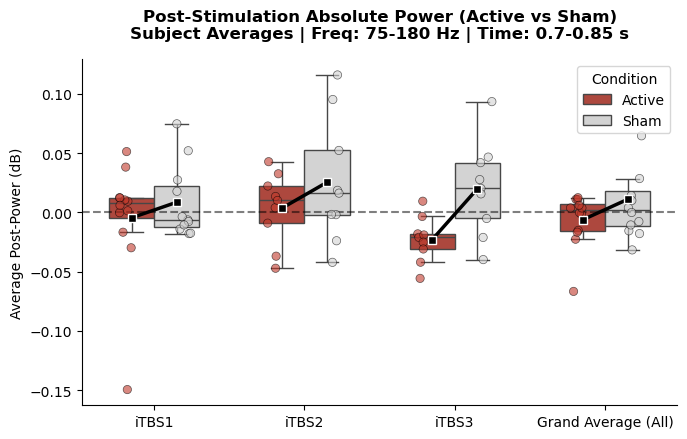

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Data Aggregation (Electrode-level -> Subject-level) ---
blocks_of_interest = ['iTBS1', 'iTBS2', 'iTBS3']

# Filter to blocks of interest
df_filtered = df_results[df_results['block'].isin(blocks_of_interest)].copy()

# Average across channels within each subject, block, and condition
df_sub_blocks = df_filtered.groupby(['subject', 'block', 'condition'], as_index=False)['post_power'].mean()

# Calculate Grand Average: Mean across all blocks per subject and condition
df_sub_ga = df_sub_blocks.groupby(['subject', 'condition'], as_index=False)['post_power'].mean()
df_sub_ga['block'] = 'Grand Average (All)'

# Combine block-specific and grand average data into a single plotting frame
df_plot = pd.concat([df_sub_blocks, df_sub_ga], ignore_index=True)

groups_to_plot = blocks_of_interest + ['Grand Average (All)']
hue_order = ['Active', 'Sham']  # Flipped order: Active first, then Sham

# --- 2. Plotting Subject Means: Active vs Sham ---
fig, ax = plt.subplots(figsize=(7, 4.5))

# Palette mapped to new hue order (Red for Active, Gray for Sham)
power_palette = {'Active': '#c0392b', 'Sham': 'lightgray'}

# Base Boxplot
sns.boxplot(
    data=df_plot, x='block', y='post_power', hue='condition', hue_order=hue_order,
    ax=ax, palette=power_palette, showfliers=False, width=0.6
)

# Overlay individual subject points with black borders
sns.stripplot(
    data=df_plot, x='block', y='post_power', hue='condition', hue_order=hue_order,
    ax=ax, palette=power_palette, alpha=0.6, size=6,
    jitter=True, dodge=True, legend=False,
    linewidth=0.5, edgecolor='black'
)

# Calculate and draw bold lines connecting Active/Sham means
for i, group in enumerate(groups_to_plot):
    # Isolate values for this specific group block
    group_data = df_plot[df_plot['block'] == group]
    
    mean_active = group_data[group_data['condition'] == 'Active']['post_power'].mean()
    mean_sham = group_data[group_data['condition'] == 'Sham']['post_power'].mean()
    
    # Define exact dodged x-coordinates matching Seaborn's layout based on hue_order
    x_active = i - 0.15 # center position of Active box (first in hue_order)
    x_sham = i + 0.15   # center position of Sham box (second in hue_order)
    
    # Plot bold line with square markers
    ax.plot(
        [x_active, x_sham], [mean_active, mean_sham], 
        color='black', linestyle='-', linewidth=2.5,
        marker='s', markersize=6, markerfacecolor='black', markeredgecolor='white',
        zorder=4  # Layered cleanly above boxplots but below individual dots
    )

# Styling adjustments
ax.axhline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.5)
ax.set_title(f"Post-Stimulation Absolute Power (Active vs Sham)\nSubject Averages | Freq: {target_freq_band[0]}-{target_freq_band[1]} Hz | Time: {target_time_window[0]}-{target_time_window[1]} s", 
             fontweight='bold', pad=15)
ax.set_ylabel('Average Post-Power (dB)')
ax.set_xlabel('')

# Clean up legend handles
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], labels[:2], title='Condition', loc='upper right')

sns.despine(ax=ax)

#plt.ylim(-0.1, 0.13)
plt.tight_layout()

#plt.savefig('./figs/post_power_subject_summary_HFA_zscore5.pdf')
plt.show()

**Mixed-effects model to test for post-active to post-sham change in power.**

**1. Reconstruct DataFrame with column for post-active vs post-sham difference**

In [10]:
import pandas as pd

# 1. Define your grouping/indexing columns that uniquely identify an electrode row
index_cols = ['subject', 'block', 'channel']  # Adjust 'channel' to 'jp_channel_1' if needed

# 2. Pivot the dataframe so 'active' and 'sham' become side-by-side columns
df_pivot = df_results.pivot(
    index=index_cols, 
    columns='condition', 
    values=['pre_power', 'post_power']
)

# Flatten the multi-level columns resulting from the pivot (e.g., ('pre_power', 'active') -> 'pre_power_active')
df_pivot.columns = [f'{metric}_{cond}' for metric, cond in df_pivot.columns]
df_pivot = df_pivot.reset_index()

# 3. Compute the active minus sham differences
df_diff = pd.DataFrame()
for col in index_cols:
    df_diff[col] = df_pivot[col]

df_diff['pre_power_diff'] = df_pivot['pre_power_Sham'] - df_pivot['pre_power_Active']
df_diff['post_power_diff'] = df_pivot['post_power_Sham'] - df_pivot['post_power_Active']

# --- Print results ---
print(f"Original shape: {df_results.shape}")
print(f"Diff dataframe shape: {df_diff.shape}")
print(df_diff[['pre_power_diff', 'post_power_diff']].head())

Original shape: (390, 9)
Diff dataframe shape: (197, 5)
   pre_power_diff  post_power_diff
0        0.062572         0.155022
1       -0.021003         0.042824
2       -0.066220         0.041611
3        0.042800        -0.070126
4       -0.037203         0.024015


**2. Test for overall effect of the difference across all blocks**

In [11]:
from patsy.contrasts import Sum

df_diff_block = df_diff[df_diff['block'].str.contains('')]
df_diff_block = df_diff_block.dropna(subset=['post_power_diff']).copy()
df_block_avg = df_diff_block.groupby(['subject', 'channel'])['post_power_diff'].mean().reset_index()

use_block_avg=False

if use_block_avg:
        
    model = smf.mixedlm("post_power_diff ~ 1", 
                        data=df_block_avg, 
                        groups=df_block_avg['subject'])
    
    result = model.fit(method='powell')

else: 

    model = smf.mixedlm("post_power_diff ~ C(block, Sum)", 
                        data=df_diff_block, 
                        groups=df_diff_block['subject'],
                       )
    
    result = model.fit(method=None)

print(result.summary())

              Mixed Linear Model Regression Results
Model:              MixedLM  Dependent Variable:  post_power_diff
No. Observations:   193      Method:              REML           
No. Groups:         12       Scale:               0.0033         
Min. group size:    1        Log-Likelihood:      258.5362       
Max. group size:    71       Converged:           Yes            
Mean group size:    16.1                                         
-----------------------------------------------------------------
                       Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------
Intercept               0.026    0.011  2.451 0.014  0.005  0.048
C(block, Sum)[S.iTBS1] -0.014    0.006 -2.355 0.019 -0.026 -0.002
C(block, Sum)[S.iTBS2] -0.001    0.006 -0.146 0.884 -0.013  0.011
Group Var               0.001    0.009                           



/Users/esolomon/anaconda3/envs/mne_development_2025/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


**Test for a linear effect on difference across blocks**

In [12]:
# Extract the numeric part from the block string (e.g., 'iTBS1' -> 1.0)
df_diff_block['block_num'] = df_diff_block['block'].str.extract('(\d+)').astype(float)

# Drop any rows where the extraction failed (just in case)
df_diff_block = df_diff_block.dropna(subset=['block_num', 'post_power_diff']).copy()

import statsmodels.formula.api as smf

# Formula: post_power_diff ~ block_num
# This fits a linear trend line across the successive blocks
model_trend = smf.mixedlm(
    "post_power_diff ~ block_num", 
    data=df_diff_block, 
    groups=df_diff_block['subject'],
    re_formula="~block_num"  # Allows the rate of increase to vary by subject
)

result_trend = model_trend.fit()
print(result_trend.summary())

             Mixed Linear Model Regression Results
Model:             MixedLM  Dependent Variable:  post_power_diff
No. Observations:  193      Method:              REML           
No. Groups:        12       Scale:               0.0032         
Min. group size:   1        Log-Likelihood:      265.0615       
Max. group size:   71       Converged:           Yes            
Mean group size:   16.1                                         
----------------------------------------------------------------
                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------
Intercept             -0.002    0.019 -0.125 0.900 -0.039  0.034
block_num              0.015    0.009  1.572 0.116 -0.004  0.033
Group Var              0.001    0.023                           
Group x block_num Cov -0.000    0.010                           
block_num Var          0.000    0.006                           



/Users/esolomon/anaconda3/envs/mne_development_2025/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
